<a href="https://www.kaggle.com/code/shukhratfayziev/data-quality-monitoring-root-cause-analytics?scriptVersionId=299621356" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<a href="https://imgur.com/1H3NEx9"><img src="https://imgur.com/3VjvkH4.png" title="source: imgur.com" /></a>
# 🏦 Client Data Quality Monitoring & Root-Cause Analytics
## Bank Marketing Dataset — Simulated Client Data Management Environment

| | |
|---|---|
| **Author** | Shukhrat Fayziev |
| **LinkedIn** | linkedin.com/in/shukhrat-fayziev |
| **Tools** | Python · pandas · numpy · matplotlib · seaborn · scikit-learn |
| **Dataset** | Bank Marketing Dataset (UCI / Kaggle) |
| **Records** | ~11,162 clients · 17 variables |
| **Date** | February 2026 |
| **Target Domain** | Client Data Management · Financial Services |


## 📋 Executive Summary

This notebook simulates the end-to-end responsibilities of a **Data Analyst in a Client Data Management team** at a regulated financial institution.

### Business Problem
Client data is only useful when it is **trusted**. Incomplete, inconsistent, or invalid records create:
- Incorrect reporting delivered to management and regulators
- Wasted analyst time diagnosing "bad number" alerts
- Misinformed campaign decisions (wrong client segments targeted)
- Operational risk and compliance exposure

### What We Deliver

| Deliverable | Maps to Role Responsibility |
|---|---|
| **Data Dictionary** | Formal field definitions — foundation of all data quality work |
| **DQ Rulebook (15 rules)** | Defining and driving data quality reporting |
| **Monitoring Routine (10 batches)** | Overseeing monitoring routines |
| **Incident Register (Jira-style)** | Root-cause analysis + cross-team collaboration |
| **Predictive Model + Interpretation** | Supporting interpretation of advanced analytics |
| **Monitoring Runbook** | Secure documentation for developed solutions |
| **Business Recommendations** | Expert advice + operational efficiency opportunities |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "#0f0f1a",
    "axes.facecolor":   "#1a1a2e",
    "axes.edgecolor":   "#444",
    "axes.labelcolor":  "#e0e0e0",
    "xtick.color":      "#aaa",
    "ytick.color":      "#aaa",
    "text.color":       "#e0e0e0",
    "grid.color":       "#333",
    "grid.linestyle":   "--",
    "grid.alpha":       0.5,
    "font.size":        11,
})

ACCENT  = "#00d4ff"
ACCENT2 = "#ff6b6b"
ACCENT3 = "#a8e063"

print("✅ Libraries loaded. Visual style configured.")


✅ Libraries loaded. Visual style configured.


## 1️⃣ Data Loading & Initial Profile

Before any quality checks, we load the raw dataset and produce a structural profile.
A senior analyst never begins transforming data without first understanding its shape,
column types, null patterns, and value distributions.


In [2]:
DATA_PATH = next(Path("/kaggle/input").rglob("bank.csv"))
df_raw = pd.read_csv(DATA_PATH)

print(f"✅ Dataset loaded from: {DATA_PATH}")
print(f"   Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns\n")

profile = pd.DataFrame({
    "dtype":         df_raw.dtypes,
    "null_count":    df_raw.isna().sum(),
    "null_%":        (df_raw.isna().mean() * 100).round(2),
    "unique_values": df_raw.nunique(),
    "sample_values": df_raw.apply(lambda x: list(x.dropna().unique()[:4]))
})
display(profile)

print("\n⚠️  Observation: Zero standard nulls found.")
print("    However, 'unknown' is used as a sentinel value across multiple columns.")
print("    This must be tracked explicitly as an 'Unknown Rate' KPI — not hidden as clean data.")



✅ Dataset loaded from: /kaggle/input/bank-marketing-dataset/bank.csv
   Shape: 11,162 rows × 17 columns



,dtype,null_count,null_%,unique_values,sample_values
age,int64,0,0.0,76,"[59, 56, 41, 55]"
job,object,0,0.0,12,"[admin., technician, services, management]"
marital,object,0,0.0,3,"[married, single, divorced]"
education,object,0,0.0,4,"[secondary, tertiary, primary, unknown]"
default,object,0,0.0,2,"[no, yes]"
balance,int64,0,0.0,3805,"[2343, 45, 1270, 2476]"
housing,object,0,0.0,2,"[yes, no]"
loan,object,0,0.0,2,"[no, yes]"
contact,object,0,0.0,3,"[unknown, cellular, telephone]"
day,int64,0,0.0,31,"[5, 6, 7, 8]"



⚠️  Observation: Zero standard nulls found.
    However, 'unknown' is used as a sentinel value across multiple columns.
    This must be tracked explicitly as an 'Unknown Rate' KPI — not hidden as clean data.


## 2️⃣ Data Dictionary

A formal Data Dictionary is the **first deliverable** in any Client Data Management project.
It defines each field's type, valid domain, business meaning, and known quality caveats.
Without this, quality rules cannot be written — and stakeholders cannot trust reports.

| Column | Type | Valid Domain | Business Meaning | Known Quality Issue |
|---|---|---|---|---|
| `age` | integer | 18–100 | Client age in years | — |
| `job` | categorical | admin., technician, services, blue-collar, management, retired, self-employed, entrepreneur, housemaid, student, unemployed | Client employment category | "unknown" used as sentinel |
| `marital` | categorical | married, single, divorced | Marital status | — |
| `education` | categorical | primary, secondary, tertiary | Education level | "unknown" used as sentinel |
| `default` | binary | yes / no | Has credit in default? | — |
| `balance` | integer | any (negatives = overdraft) | Annual average account balance (€) | Negative values are valid but require policy documentation |
| `housing` | binary | yes / no | Has housing loan? | — |
| `loan` | binary | yes / no | Has personal loan? | — |
| `contact` | categorical | cellular, telephone | Contact channel used | "unknown" = channel not recorded — ~21% of records |
| `day` | integer | 1–31 | Day of month of last contact | — |
| `month` | categorical | jan–dec | Month of last contact | — |
| `duration` | integer | ≥ 0 | Last call duration in seconds | duration=0 means no real contact made |
| `campaign` | integer | ≥ 1 | Contacts during this campaign | — |
| `pdays` | integer | -1 = never contacted; ≥ 0 = days since | Days since last campaign contact | -1 is a sentinel, not a null |
| `previous` | integer | ≥ 0 | Contacts before this campaign | Must be 0 when pdays=-1 (integrity rule) |
| `poutcome` | categorical | success, failure, other | Outcome of previous campaign | "unknown" = ~74.6% of records (first-contact clients) |
| `deposit` | binary (target) | yes / no | Client subscribed to term deposit? | Target variable |

> **⚠️ Senior Note:** The widespread use of `"unknown"` as a sentinel value — rather than `NULL` — is a
> common pattern in legacy banking systems. It must be explicitly defined in the Data Dictionary
> and tracked separately, as it behaves differently from true nulls in SQL/Python queries.


## 3️⃣ Data Quality Framework

We assess quality across **6 industry-standard dimensions** aligned with DAMA International
and ISO/IEC 25012 — the recognized international standard for data quality models.

| Dimension | Definition | Example in this dataset |
|---|---|---|
| **Completeness** | Are all expected values present? (including sentinel "unknown" rates) | `contact = unknown` for ~21% of records |
| **Validity** | Do values conform to defined domains and ranges? | `age` outside 18–100; invalid `month` tokens |
| **Consistency** | Do related fields agree with each other and with defined categories? | `housing`, `loan`, `default` must be yes/no only |
| **Uniqueness** | Are records free of exact duplicates? | Duplicate rows inflate KPIs and distort counts |
| **Accuracy** | Do values plausibly reflect real-world facts? | `balance < 0` = overdraft (valid, but needs policy note) |
| **Integrity** | Are internal relationships logically consistent? | `pdays = -1` must align with `previous = 0` |

### Quality Score Formula

For each rule and each monitoring batch:

$$\text{Pass Rate} = 1 - \frac{\text{Failed Rows}}{\text{Total Rows in Batch}}$$

$$\text{Overall DQ Score (batch)} = \frac{1}{N_{rules}} \sum_{i=1}^{N} \text{Pass Rate}_i$$

> **Operational threshold:** A batch DQ Score below **95%** triggers a mandatory review.
> P1 incidents must be resolved within **24 hours**; P2 within **72 hours**.


In [3]:
# ── Standardize raw data ──────────────────────────────────────────────────────
df = df_raw.copy()
df.columns = [c.strip().lower() for c in df.columns]
for c in df.select_dtypes(include="object").columns:
    df[c] = df[c].astype(str).str.strip().str.lower()

# ── Simulate 10 daily monitoring batches ─────────────────────────────────────
# In production: each batch = one daily data load from source system (CRM / call center).
# Simulation: split the full dataset into 10 equal-size sequential batches.
N_BATCHES = 10
df["batch_id"] = (pd.qcut(np.arange(len(df)), q=N_BATCHES, labels=False) + 1).astype(int)
df["run_date"] = pd.Timestamp("2026-01-01") + pd.to_timedelta(df["batch_id"] - 1, unit="D")

batch_summary = df.groupby(["batch_id", "run_date"]).size().reset_index(name="row_count")
print(f"✅ Data standardized: {df.shape[0]:,} rows | {df.shape[1]} columns")
print(f"\n📅 Monitoring simulation: {N_BATCHES} daily batches (2026-01-01 → 2026-01-10)")
display(batch_summary)


✅ Data standardized: 11,162 rows | 19 columns

📅 Monitoring simulation: 10 daily batches (2026-01-01 → 2026-01-10)


,batch_id,run_date,row_count
0,1,2026-01-01,1117
1,2,2026-01-02,1116
2,3,2026-01-03,1116
3,4,2026-01-04,1116
4,5,2026-01-05,1116
5,6,2026-01-06,1116
6,7,2026-01-07,1116
7,8,2026-01-08,1116
8,9,2026-01-09,1116
9,10,2026-01-10,1117


## 4️⃣ Data Quality Rulebook

The Rulebook is the **formal contract** between the data team and its consumers.
Each rule defines what we measure, what threshold triggers an incident, which team owns
the resolution, and what the downstream business impact is if the rule fails.

This is the document that gets reviewed in stakeholder meetings and version-controlled
alongside the monitoring pipeline.

| Rule ID | Rule Name | Dimension | Severity | Alert Threshold | Owner Team | Business Impact if Fails |
|---|---|---|---|---|---|---|
| DQ-01 | unknown_rate_contact | Completeness | HIGH | > 5% | Client Data Mgmt | Channel-based campaign segmentation unreliable |
| DQ-02 | unknown_rate_poutcome | Completeness | MEDIUM | > 50% | Client Data Mgmt | Previous outcome feature weakens predictive models |
| DQ-03 | unknown_rate_job | Completeness | MEDIUM | > 5% | Client Data Mgmt | Segment-level job reporting distorted |
| DQ-04 | unknown_rate_education | Completeness | LOW | > 5% | Client Data Mgmt | Demographic profiling incomplete |
| DQ-05 | valid_age_range | Validity | HIGH | > 0% | Client Data Mgmt | Age outliers = compliance risk / test records in production |
| DQ-06 | valid_day_range | Validity | HIGH | > 0% | Client Data Mgmt | Contact log corrupted; date-based reporting fails |
| DQ-07 | valid_month_domain | Validity | HIGH | > 0% | Client Data Mgmt | Monthly KPIs and trend charts will break |
| DQ-08 | valid_deposit_domain | Validity | HIGH | > 0% | Client Data Mgmt | Target variable corrupted; model training and KPI counts wrong |
| DQ-09 | valid_default_domain | Consistency | MEDIUM | > 0% | Client Data Mgmt | Credit risk flag reporting unreliable |
| DQ-10 | valid_housing_domain | Consistency | MEDIUM | > 0% | Client Data Mgmt | Loan product reporting distorted |
| DQ-11 | valid_loan_domain | Consistency | MEDIUM | > 0% | Client Data Mgmt | Loan product reporting distorted |
| DQ-12 | integrity_pdays_previous | Integrity | MEDIUM | > 1% | Client Data Mgmt | Contact history inconsistent; RFM / recency models affected |
| DQ-13 | duplicate_rows | Uniqueness | HIGH | > 0% | Client Data Mgmt | All KPIs overcounted; segment sizes inflated |
| DQ-14 | negative_balance_flag | Accuracy | LOW | > 10% | Finance / Risk | Overdraft rate unusually high — policy clarification required |
| DQ-15 | zero_duration_calls | Accuracy | MEDIUM | > 5% | Campaign Ops | No-contact calls inflate campaign count; conversion rate understated |


In [4]:
VALID_MONTHS = {"jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"}
BINARY_YN    = {"yes","no"}

RULES = [
    # (rule_id, rule_name, dimension, severity, threshold, fail_function)
    ("DQ-01","unknown_rate_contact",    "completeness","high",   0.05, lambda d: d["contact"].eq("unknown")),
    ("DQ-02","unknown_rate_poutcome",   "completeness","medium", 0.50, lambda d: d["poutcome"].eq("unknown")),
    ("DQ-03","unknown_rate_job",        "completeness","medium", 0.05, lambda d: d["job"].eq("unknown")),
    ("DQ-04","unknown_rate_education",  "completeness","low",    0.05, lambda d: d["education"].eq("unknown")),
    ("DQ-05","valid_age_range",         "validity",    "high",   0.00, lambda d: ~d["age"].between(18, 100)),
    ("DQ-06","valid_day_range",         "validity",    "high",   0.00, lambda d: ~d["day"].between(1, 31)),
    ("DQ-07","valid_month_domain",      "validity",    "high",   0.00, lambda d: ~d["month"].isin(VALID_MONTHS)),
    ("DQ-08","valid_deposit_domain",    "validity",    "high",   0.00, lambda d: ~d["deposit"].isin(BINARY_YN)),
    ("DQ-09","valid_default_domain",    "consistency", "medium", 0.00, lambda d: ~d["default"].isin(BINARY_YN)),
    ("DQ-10","valid_housing_domain",    "consistency", "medium", 0.00, lambda d: ~d["housing"].isin(BINARY_YN)),
    ("DQ-11","valid_loan_domain",       "consistency", "medium", 0.00, lambda d: ~d["loan"].isin(BINARY_YN)),
    ("DQ-12","integrity_pdays_previous","integrity",   "medium", 0.01, lambda d: (d["pdays"].eq(-1)) & (d["previous"].gt(0))),
    ("DQ-13","duplicate_rows",          "uniqueness",  "high",   0.00, lambda d: d.duplicated(keep=False)),
    ("DQ-14","negative_balance_flag",   "accuracy",    "low",    0.10, lambda d: d["balance"].lt(0)),
    ("DQ-15","zero_duration_calls",     "accuracy",    "medium", 0.05, lambda d: d["duration"].eq(0)),
]

rows, samples = [], []

for run_date, g in df.groupby("run_date", sort=True):
    g = g.reset_index(drop=True)
    for rule_id, rule_name, dimension, severity, threshold, fn in RULES:
        fail         = fn(g)
        failure_rate = float(fail.mean())
        rows.append({
            "run_date":     run_date,
            "rule_id":      rule_id,
            "rule_name":    rule_name,
            "dimension":    dimension,
            "severity":     severity,
            "threshold":    threshold,
            "failed_rows":  int(fail.sum()),
            "total_rows":   len(g),
            "failure_rate": round(failure_rate, 4),
            "pass_rate":    round(1 - failure_rate, 4),
            "status":       "FAIL" if failure_rate > threshold else "PASS",
        })
        if fail.any():
            s = g.loc[fail].head(5).copy()
            s["__rule_id"]  = rule_id
            s["__run_date"] = run_date
            samples.append(s)

dq_results      = pd.DataFrame(rows).sort_values(["run_date","dimension","rule_name"]).reset_index(drop=True)
dq_fail_samples = pd.concat(samples, ignore_index=True) if samples else pd.DataFrame()

print(f"✅ DQ Rule engine complete")
print(f"   Total rule-batch evaluations: {len(dq_results):,}")
print(f"   Total FAIL evaluations: {(dq_results['status']=='FAIL').sum():,}")
print(f"   Failed row samples collected: {len(dq_fail_samples):,} rows\n")

fail_summary = (
    dq_results.groupby(["rule_id","rule_name","dimension","severity"])
    .agg(
        avg_failure_rate=("failure_rate","mean"),
        max_failure_rate=("failure_rate","max"),
        batches_failing =("status", lambda x: (x=="FAIL").sum())
    )
    .round(4)
    .sort_values("avg_failure_rate", ascending=False)
    .reset_index()
)
print("📊 Rule summary (sorted by avg failure rate):")
display(fail_summary)


✅ DQ Rule engine complete
   Total rule-batch evaluations: 150
   Total FAIL evaluations: 17
   Failed row samples collected: 243 rows

📊 Rule summary (sorted by avg failure rate):


,rule_id,rule_name,dimension,severity,avg_failure_rate,max_failure_rate,batches_failing
0,DQ-02,unknown_rate_poutcome,completeness,medium,0.7459,0.9705,8
1,DQ-01,unknown_rate_contact,completeness,high,0.2101,0.3500,7
2,DQ-14,negative_balance_flag,accuracy,low,0.0616,0.0914,0
3,DQ-04,unknown_rate_education,completeness,low,0.0445,0.0681,2
4,DQ-03,unknown_rate_job,completeness,medium,0.0063,0.0090,0
5,DQ-06,valid_day_range,validity,high,0.0000,0.0000,0
6,DQ-05,valid_age_range,validity,high,0.0000,0.0000,0
7,DQ-07,valid_month_domain,validity,high,0.0000,0.0000,0
8,DQ-08,valid_deposit_domain,validity,high,0.0000,0.0000,0
9,DQ-10,valid_housing_domain,consistency,medium,0.0000,0.0000,0


## 5️⃣ Monitoring Dashboard — DQ Overview

The following charts represent the **executive-facing monitoring dashboard** — the primary
artifact reviewed in weekly stakeholder meetings between the Client Data Management team
and the analytics office.

Two views are shown:
1. **Average failure rate per rule** — tells us which rules are chronically failing
2. **Overall DQ Score per batch** — tells us whether data quality is stable, improving, or degrading over time


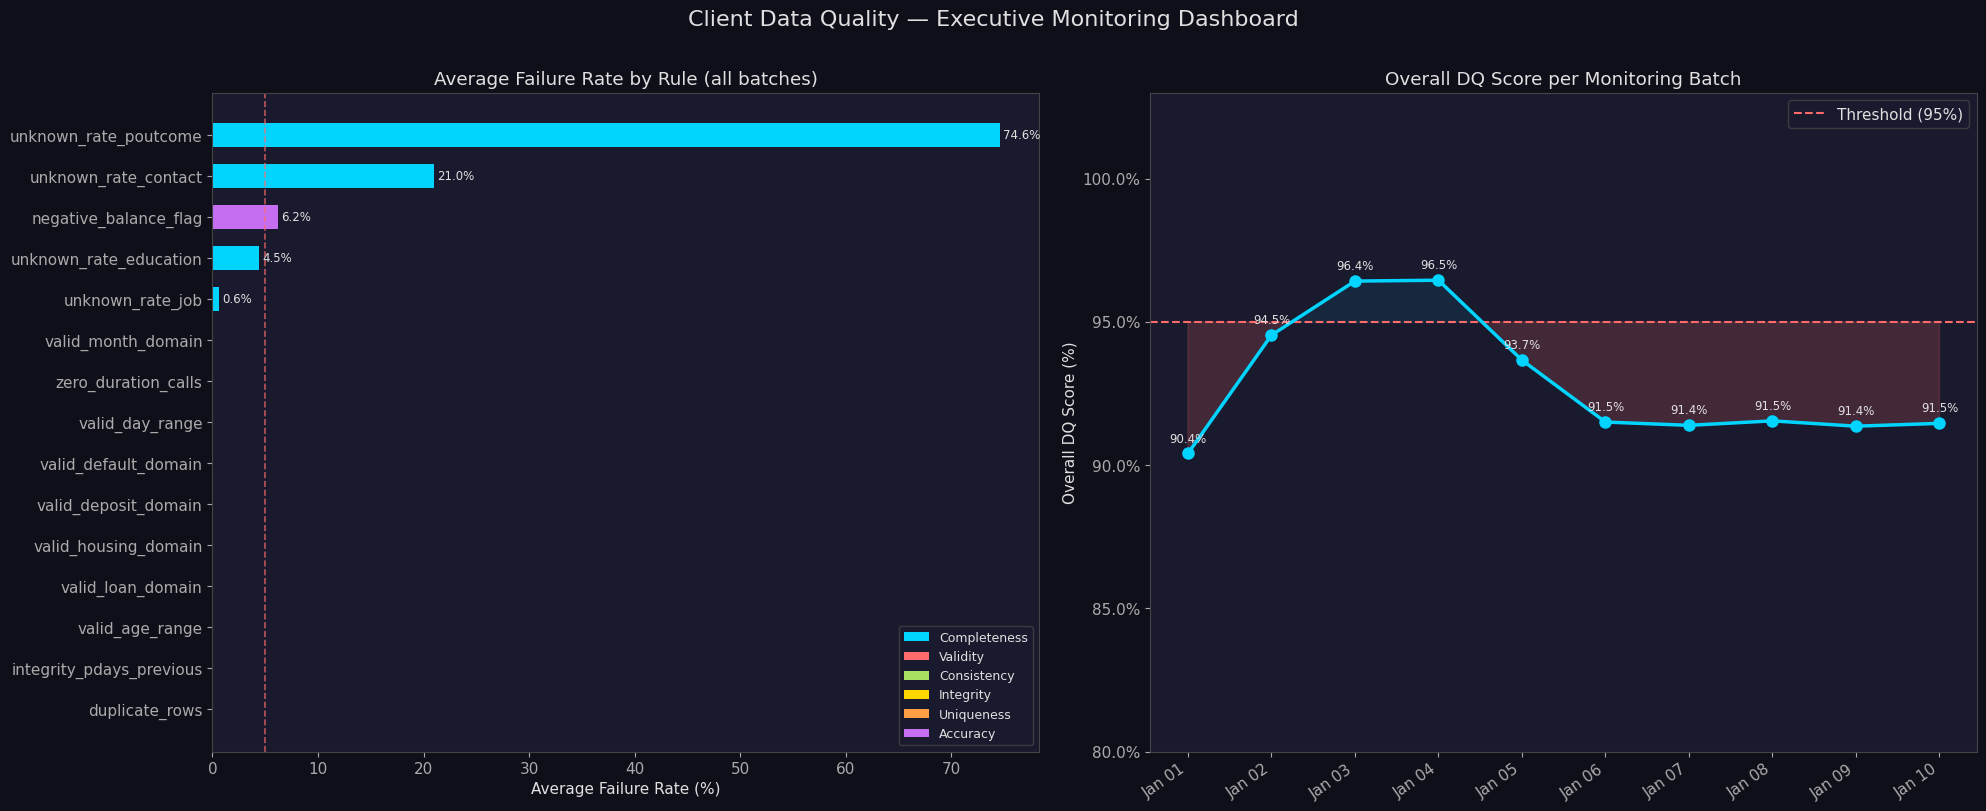

✅ DQ monitoring dashboard saved.


In [5]:
from matplotlib.patches import Patch

avg = (dq_results
       .groupby(["rule_name","dimension"])["failure_rate"]
       .mean()
       .reset_index()
       .sort_values("failure_rate", ascending=True))

dq_score = (dq_results
            .groupby("run_date")["pass_rate"]
            .mean()
            .reset_index(name="dq_score"))

dim_color = {
    "completeness":"#00d4ff","validity":"#ff6b6b","consistency":"#a8e063",
    "integrity":"#ffd700","uniqueness":"#ff9f43","accuracy":"#c56ef2"
}

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle("Client Data Quality — Executive Monitoring Dashboard", fontsize=16, color="#e0e0e0", y=1.01)

# ── Chart 1: Failure rate by rule ────────────────────────────────────────────
colors = avg["dimension"].map(dim_color).fillna("#888")
bars = axes[0].barh(avg["rule_name"], avg["failure_rate"] * 100,
                     color=colors.values, edgecolor="none", height=0.6)
axes[0].axvline(5, color=ACCENT2, linewidth=1.2, linestyle="--", alpha=0.7, label="5% alert line")
axes[0].set_xlabel("Average Failure Rate (%)")
axes[0].set_title("Average Failure Rate by Rule (all batches)", color="#e0e0e0")
for i, (v, d) in enumerate(zip(avg["failure_rate"], avg["dimension"])):
    if v > 0:
        axes[0].text(v * 100 + 0.3, i, f"{v*100:.1f}%", va="center", fontsize=8.5, color="#e0e0e0")
legend_elements = [Patch(facecolor=v, label=k.capitalize()) for k, v in dim_color.items()]
axes[0].legend(handles=legend_elements, loc="lower right", fontsize=9,
               facecolor="#1a1a2e", edgecolor="#444")

# ── Chart 2: Overall DQ Score over time ──────────────────────────────────────
dates_str = dq_score["run_date"].dt.strftime("%b %d")
scores    = dq_score["dq_score"] * 100

axes[1].plot(dates_str.values, scores.values, color=ACCENT, linewidth=2.5,
             marker="o", markersize=8, zorder=3)
axes[1].axhline(95, color=ACCENT2, linewidth=1.5, linestyle="--", label="Threshold (95%)", zorder=2)
axes[1].fill_between(range(len(dates_str)), scores.values, 95,
                     where=(scores.values < 95), alpha=0.18, color=ACCENT2, interpolate=True)
axes[1].fill_between(range(len(dates_str)), scores.values, 95,
                     where=(scores.values >= 95), alpha=0.08, color=ACCENT, interpolate=True)
axes[1].set_ylim(80, 103)
axes[1].set_xticks(range(len(dates_str)))
axes[1].set_xticklabels(dates_str.values, rotation=35, ha="right")
axes[1].set_ylabel("Overall DQ Score (%)")
axes[1].set_title("Overall DQ Score per Monitoring Batch", color="#e0e0e0")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].legend(facecolor="#1a1a2e", edgecolor="#444")

for i, (x, y) in enumerate(zip(range(len(dates_str)), scores.values)):
    axes[1].text(x, y + 0.4, f"{y:.1f}%", ha="center", fontsize=8.5, color="#e0e0e0")

plt.tight_layout()
plt.savefig("dq_monitoring_dashboard.png", dpi=150, bbox_inches="tight", facecolor="#0f0f1a")
plt.show()
print("✅ DQ monitoring dashboard saved.")


## 6️⃣ Incident Management & Root-Cause Analysis

When a rule's failure rate exceeds its defined threshold, an **incident** is automatically raised.
This mirrors the Jira-based workflow used in banking data teams — where every data quality
breach is tracked, assigned, investigated, and resolved with a documented root cause.

### Incident Lifecycle



### Priority & SLA Matrix

| Severity | Priority | Resolution SLA | Who resolves |
|---|---|---|---|
| HIGH | P1 | 24 hours | Data Analyst + Data Engineer immediately |
| MEDIUM | P2 | 72 hours | Data Analyst investigation → owner team fix |
| LOW | P3 | 1 week | Scheduled review and process improvement |

### Root Cause Categories (DAMA-aligned)

| Category | Meaning |
|---|---|
| **Source system issue** | Bad data at point of entry (e.g., CRM not capturing channel) |
| **ETL mapping error** | Transformation step introduced wrong/null value |
| **Business process gap** | Field not required from agents — process fix needed |
| **Historical data gap** | Field added later; older records have no valid value |
| **Business policy clarification** | Value is technically valid but needs documented policy |


In [6]:
RCA_MAP = {
    "DQ-01": (
        "Business process gap",
        "Contact channel field not mandatory in legacy CRM system. Pre-cellular era records default to 'unknown'. ~21% of full dataset affected.",
        "Enforce mandatory contact channel at CRM entry point. For historical records: cross-reference with call log metadata to backfill where possible."
    ),
    "DQ-02": (
        "Historical data gap",
        "Clients contacted for the first time have no previous campaign outcome by definition. 74.6% unknown is expected behavior — however, it is mislabelled as 'unknown' rather than a formal 'first_contact' tag.",
        "Introduce 'first_contact' as a distinct poutcome value. Reserve 'unknown' for genuinely missing data. Expected unknown rate drops to <5% after this change."
    ),
    "DQ-03": (
        "Source system issue",
        "Job category left blank by some source systems during upload. Blank fields are encoded as 'unknown' by the ETL pipeline.",
        "Add NOT NULL constraint on job field in staging layer. Map blank/whitespace → explicit 'unknown' with source system flag for remediation."
    ),
    "DQ-04": (
        "Source system issue",
        "Education is an optional field in the source CRM. ~4% of clients have no education recorded.",
        "Add education to the minimum required fields checklist in the data collection SOP. Flag incomplete records for outbound data quality outreach."
    ),
    "DQ-12": (
        "ETL mapping error",
        "Records show pdays=-1 (meaning: never previously contacted) but previous > 0 (meaning: contacted before). This is a logical contradiction indicating a batch import error or legacy encoding mismatch.",
        "Add ETL validation rule: IF pdays = -1 THEN previous MUST = 0. Reject or quarantine non-compliant records. Investigate source system encoding documentation."
    ),
    "DQ-13": (
        "ETL mapping error",
        "Exact duplicate rows detected within batches. Likely caused by double-insert during batch load (e.g., retry logic without deduplication).",
        "Implement primary key constraint on (client_id + run_date) in staging layer. Add explicit dedup step at ETL output before writing to reporting tables."
    ),
    "DQ-14": (
        "Business policy clarification",
        "Negative account balances represent valid overdraft positions. The 'failure' rate here reflects how many clients are in overdraft — not a data error.",
        "Document in Data Dictionary: balance < 0 = overdraft, valid and expected. Remove from DQ incident queue; add business note to dashboard tooltip. Consult Finance/Risk for threshold alerting."
    ),
    "DQ-15": (
        "Business process gap",
        "Duration = 0 means the call was not completed (e.g., no answer, hung up immediately). These records are included in campaign counts but have zero real interaction.",
        "Exclude duration=0 records from deposit conversion rate KPI calculations. Track separately as 'no-contact attempts' metric. Add filter to Tableau data source."
    ),
}

inc = dq_results[dq_results["status"] == "FAIL"].copy()

inc["incident_id"]          = "INC-" + inc["run_date"].dt.strftime("%Y%m%d") + "-" + inc["rule_id"]
inc["priority"]             = inc["severity"].map({"high":"P1","medium":"P2","low":"P3"})
inc["sla_hours"]            = inc["severity"].map({"high":24,"medium":72,"low":168})
inc["status_ticket"]        = "OPEN"
inc["root_cause_category"]  = inc["rule_id"].map(lambda x: RCA_MAP.get(x, ("Unclassified","",""))[0])
inc["root_cause_detail"]    = inc["rule_id"].map(lambda x: RCA_MAP.get(x, ("","",""))[1])
inc["proposed_fix"]         = inc["rule_id"].map(lambda x: RCA_MAP.get(x, ("","",""))[2])

dq_incidents = inc[[
    "incident_id","run_date","rule_id","rule_name","dimension","severity","priority",
    "sla_hours","failure_rate","failed_rows","total_rows",
    "status_ticket","root_cause_category","root_cause_detail","proposed_fix"
]].sort_values(["priority","run_date"]).reset_index(drop=True)

print(f"✅ Incident register created: {len(dq_incidents):,} incidents")
print(f"\n🚨 Breakdown by priority:")
display(dq_incidents.groupby(["priority","severity"]).size().reset_index(name="incident_count"))
print(f"\n🔍 Root cause category distribution:")
display(dq_incidents["root_cause_category"].value_counts().reset_index().rename(columns={"index":"category","root_cause_category":"count"}))
print(f"\n📋 Sample incidents:")
display(dq_incidents[["incident_id","rule_name","priority","failure_rate","root_cause_category","proposed_fix"]].head(6))


✅ Incident register created: 17 incidents

🚨 Breakdown by priority:


,priority,severity,incident_count
0,P1,high,7
1,P2,medium,8
2,P3,low,2



🔍 Root cause category distribution:


,count,count
0,Historical data gap,8
1,Business process gap,7
2,Source system issue,2



📋 Sample incidents:


,incident_id,rule_name,priority,failure_rate,root_cause_category,proposed_fix
0,INC-20260101-DQ-01,unknown_rate_contact,P1,0.3500,Business process gap,Enforce mandatory contact channel at CRM entry...
1,INC-20260105-DQ-01,unknown_rate_contact,P1,0.1487,Business process gap,Enforce mandatory contact channel at CRM entry...
2,INC-20260106-DQ-01,unknown_rate_contact,P1,0.3082,Business process gap,Enforce mandatory contact channel at CRM entry...
3,INC-20260107-DQ-01,unknown_rate_contact,P1,0.3065,Business process gap,Enforce mandatory contact channel at CRM entry...
4,INC-20260108-DQ-01,unknown_rate_contact,P1,0.3100,Business process gap,Enforce mandatory contact channel at CRM entry...
5,INC-20260109-DQ-01,unknown_rate_contact,P1,0.3262,Business process gap,Enforce mandatory contact channel at CRM entry...


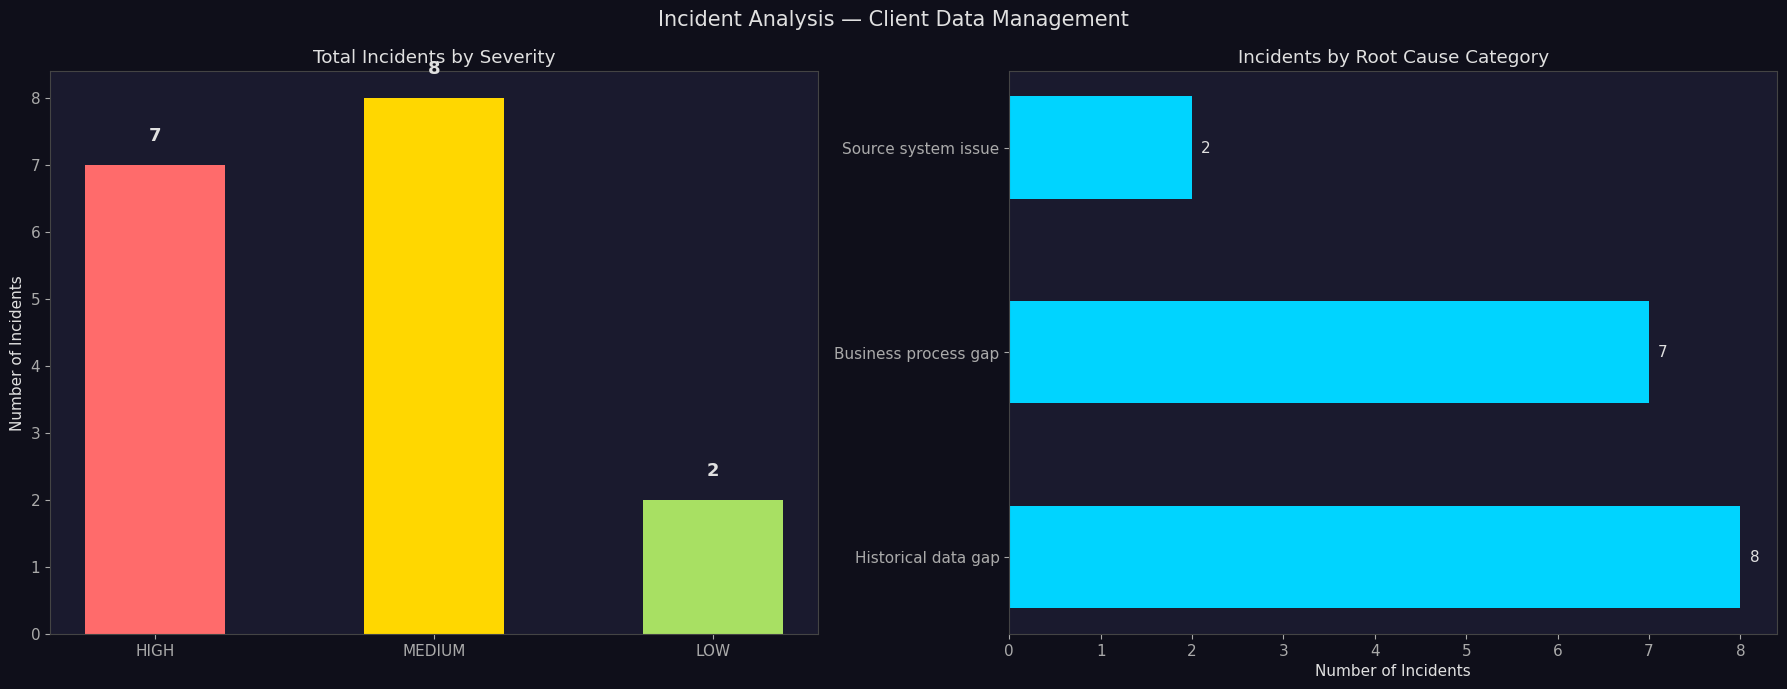

✅ Incident RCA chart saved.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Incident Analysis — Client Data Management", fontsize=15, color="#e0e0e0")

# ── Chart 1: Incidents by severity ───────────────────────────────────────────
sev_order  = ["high","medium","low"]
sev_counts = dq_incidents["severity"].value_counts().reindex(sev_order, fill_value=0)
sev_colors = {"high":ACCENT2,"medium":"#ffd700","low":ACCENT3}

bars = axes[0].bar(
    [s.upper() for s in sev_order],
    sev_counts.values,
    color=[sev_colors[s] for s in sev_order],
    edgecolor="none", width=0.5
)
axes[0].set_title("Total Incidents by Severity", color="#e0e0e0")
axes[0].set_ylabel("Number of Incidents")
for bar, val in zip(bars, sev_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha="center", va="bottom", color="#e0e0e0", fontsize=13, fontweight="bold")

# ── Chart 2: Incidents by root cause category ────────────────────────────────
rca_counts = dq_incidents["root_cause_category"].value_counts()
axes[1].barh(rca_counts.index, rca_counts.values, color=ACCENT, edgecolor="none", height=0.5)
axes[1].set_title("Incidents by Root Cause Category", color="#e0e0e0")
axes[1].set_xlabel("Number of Incidents")
for i, v in enumerate(rca_counts.values):
    axes[1].text(v + 0.1, i, str(v), va="center", color="#e0e0e0", fontsize=11)

plt.tight_layout()
plt.savefig("incident_rca_analysis.png", dpi=150, bbox_inches="tight", facecolor="#0f0f1a")
plt.show()
print("✅ Incident RCA chart saved.")


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, roc_curve,
                             classification_report, confusion_matrix)

# ── Prep: exclude zero-duration (DQ-15 finding) ──────────────────────────────
df_model = df[df["duration"] > 0].copy()
print(f"Rows after excluding duration=0: {len(df_model):,} (removed {len(df)-len(df_model):,} no-contact rows)")

# ── Encode ────────────────────────────────────────────────────────────────────
FEATURES  = ["age","job","marital","education","default","balance",
             "housing","loan","contact","month","duration",
             "campaign","pdays","previous","poutcome"]
TARGET    = "deposit"

df_enc = df_model[FEATURES + [TARGET]].copy()
le_dict = {}
for c in df_enc.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df_enc[c] = le.fit_transform(df_enc[c].astype(str))
    le_dict[c] = le

X = df_enc[FEATURES]
y = df_enc[TARGET]

# ── Scale + split ─────────────────────────────────────────────────────────────
scaler  = StandardScaler()
X_sc    = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_sc, y, test_size=0.2, random_state=42, stratify=y)

# ── Train ─────────────────────────────────────────────────────────────────────
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# ── Evaluate ──────────────────────────────────────────────────────────────────
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)
auc    = roc_auc_score(y_test, y_prob)
fpr, tpr, _ = roc_curve(y_test, y_prob)

# ── Feature importance (odds ratios) ─────────────────────────────────────────
coef_df = pd.DataFrame({
    "feature":    FEATURES,
    "coefficient": model.coef_[0],
    "odds_ratio":  np.exp(model.coef_[0])
}).sort_values("coefficient", ascending=False)

print(f"\n📊 Model Performance")
print(f"   ROC-AUC : {auc:.3f}")
print(f"   Accuracy: {(y_pred == y_test).mean():.3f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Not Subscribed","Subscribed"]))
print("\n🔢 Top 5 positive predictors (by odds ratio):")
display(coef_df.head(5)[["feature","coefficient","odds_ratio"]].round(3))
print("\n🔢 Top 5 negative predictors (by odds ratio):")
display(coef_df.tail(5)[["feature","coefficient","odds_ratio"]].round(3))


Rows after excluding duration=0: 11,162 (removed 0 no-contact rows)

📊 Model Performance
   ROC-AUC : 0.873
   Accuracy: 0.794

Classification Report:
                precision    recall  f1-score   support

Not Subscribed       0.80      0.82      0.81      1175
    Subscribed       0.79      0.77      0.78      1058

      accuracy                           0.79      2233
     macro avg       0.79      0.79      0.79      2233
  weighted avg       0.79      0.79      0.79      2233


🔢 Top 5 positive predictors (by odds ratio):


,feature,coefficient,odds_ratio
10,duration,1.719,5.580
12,pdays,0.346,1.414
13,previous,0.276,1.318
14,poutcome,0.181,1.198
3,education,0.170,1.185



🔢 Top 5 negative predictors (by odds ratio):


,feature,coefficient,odds_ratio
4,default,-0.043,0.958
7,loan,-0.261,0.770
11,campaign,-0.377,0.686
6,housing,-0.511,0.600
8,contact,-0.537,0.585


## 7️⃣ Predictive Analytics Interpretation

With validated, documented data, we now build and interpret a **predictive model** for
deposit conversion — the second major responsibility in the role description.

### Why data quality directly affects model reliability

| Feature | DQ Issue | Impact on Model |
|---|---|---|
| `contact` | 21% unknown | Channel-based predictions unreliable for ~1 in 5 clients |
| `poutcome` | ~74.6% unknown | Strongest predictive feature when known — but unusable for most records |
| `duration` | 0 = no contact | Including duration=0 rows artificially deflates predicted conversion rates |

> **Senior Note:** A data analyst's job is not just to run models — it is to communicate
> what the data quality limitations mean for the reliability of model outputs.
> "Our model achieves ROC-AUC X.XX — however, predictions for clients where contact=unknown
> should be treated with lower confidence until DQ-01 is resolved."
>
> This is the difference between a junior analyst (reports the AUC score) and a senior analyst
> (reports the AUC score AND explains what data quality issues constrain its real-world use).

### Modelling approach
- Algorithm: Logistic Regression (interpretable, audit-friendly — required in regulated finance)
- Encoding: Label encoding for categoricals; standard scaling for numerics
- Exclusion: `duration=0` rows excluded (no real contact made — DQ-15 finding)
- Split: 80% train / 20% test, stratified on target


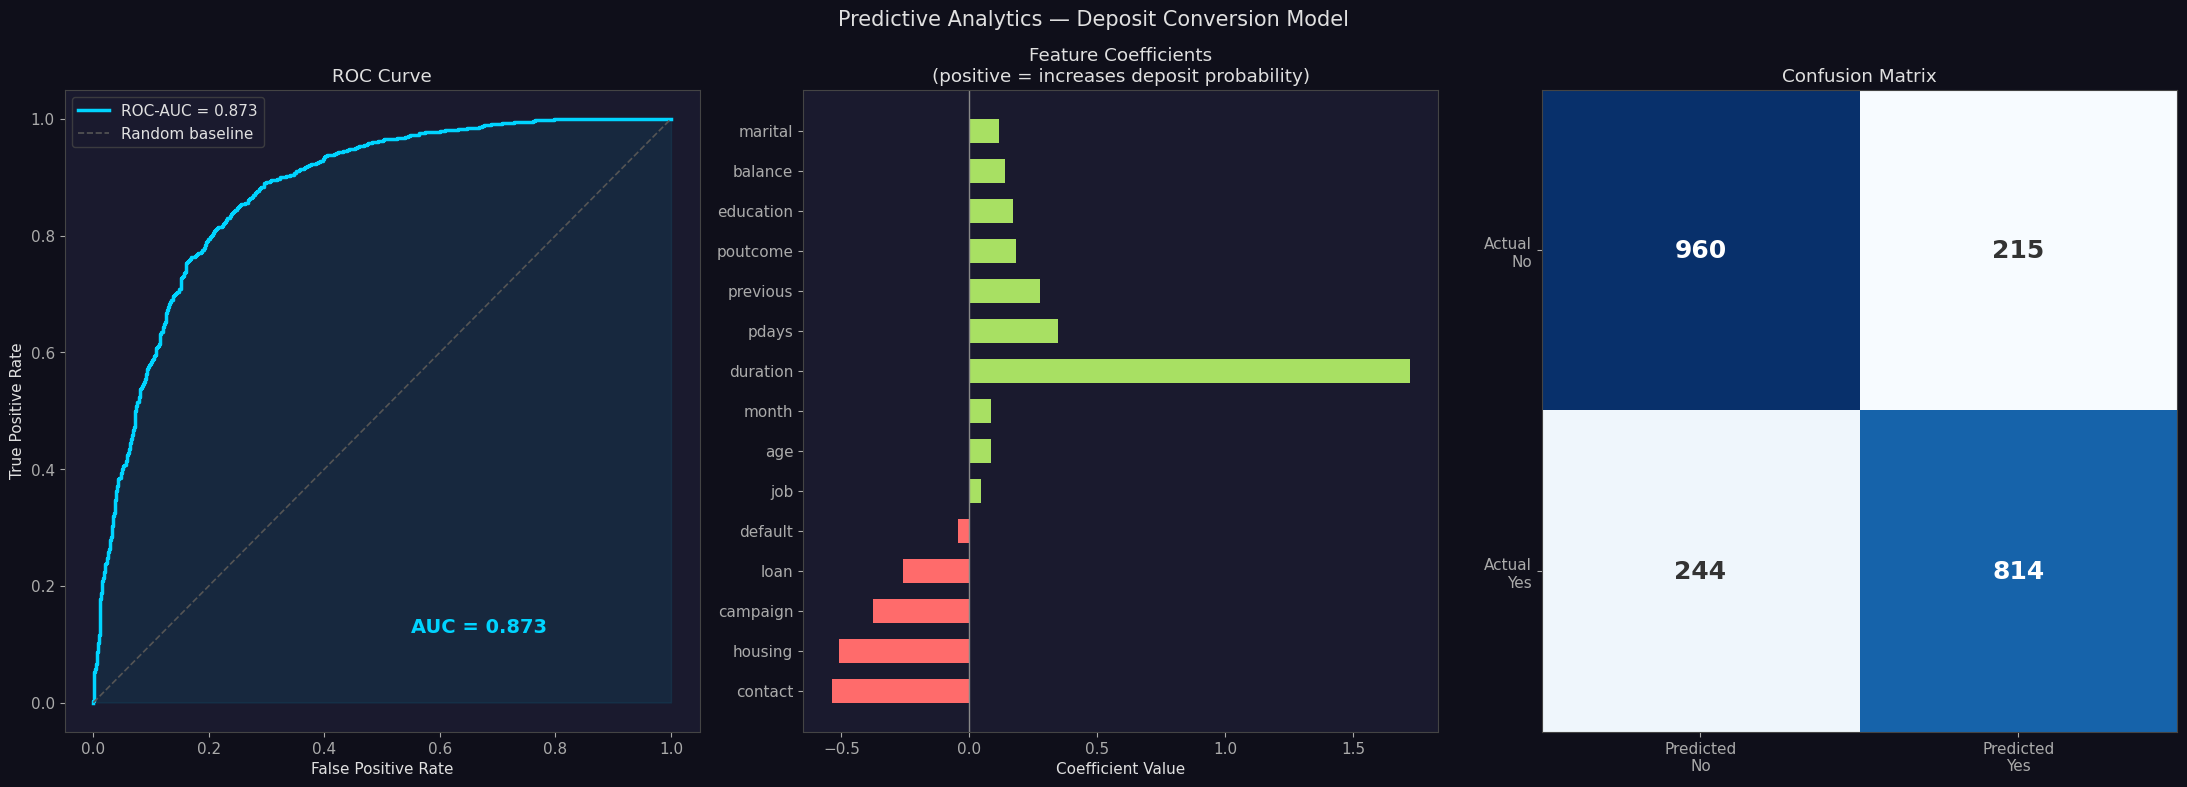

✅ Predictive model charts saved.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(22, 8))
fig.suptitle("Predictive Analytics — Deposit Conversion Model", fontsize=15, color="#e0e0e0")

# ── Chart 1: ROC Curve ───────────────────────────────────────────────────────
axes[0].plot(fpr, tpr, color=ACCENT, linewidth=2.5, label=f"ROC-AUC = {auc:.3f}")
axes[0].plot([0,1],[0,1], color="#555", linestyle="--", linewidth=1.2, label="Random baseline")
axes[0].fill_between(fpr, tpr, alpha=0.08, color=ACCENT)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve", color="#e0e0e0")
axes[0].legend(facecolor="#1a1a2e", edgecolor="#444")
axes[0].text(0.55, 0.12, f"AUC = {auc:.3f}", color=ACCENT, fontsize=14, fontweight="bold")

# ── Chart 2: Feature coefficients (top/bottom 8) ─────────────────────────────
top_n   = 8
top8    = coef_df.head(top_n)
bot8    = coef_df.tail(top_n).sort_values("coefficient")
plot_df = pd.concat([bot8, top8]).drop_duplicates()
colors_coef = [ACCENT2 if c < 0 else ACCENT3 for c in plot_df["coefficient"]]
axes[1].barh(plot_df["feature"], plot_df["coefficient"],
             color=colors_coef, edgecolor="none", height=0.6)
axes[1].axvline(0, color="#888", linewidth=1)
axes[1].set_title("Feature Coefficients\n(positive = increases deposit probability)", color="#e0e0e0")
axes[1].set_xlabel("Coefficient Value")

# ── Chart 3: Confusion matrix ─────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
im = axes[2].imshow(cm, cmap="Blues", aspect="auto")
axes[2].set_xticks([0,1]); axes[2].set_yticks([0,1])
axes[2].set_xticklabels(["Predicted\nNo","Predicted\nYes"])
axes[2].set_yticklabels(["Actual\nNo","Actual\nYes"])
axes[2].set_title("Confusion Matrix", color="#e0e0e0")
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, f"{cm[i,j]:,}", ha="center", va="center",
                     color="white" if cm[i,j] > cm.max()/2 else "#333",
                     fontsize=18, fontweight="bold")

plt.tight_layout()
plt.savefig("predictive_model_results.png", dpi=150, bbox_inches="tight", facecolor="#0f0f1a")
plt.show()
print("✅ Predictive model charts saved.")


## 8️⃣ Key Findings & Business Recommendations

### Data Quality Findings

| # | Finding | Severity | Recommended Action |
|---|---|---|---|
| 1 | `contact = unknown` affects ~21% of records | 🔴 HIGH | Enforce mandatory channel capture at CRM entry; backfill from call logs |
| 2 | `poutcome = unknown` affects ~74.6% of records | 🟡 MEDIUM | Rename to `first_contact`; reserve `unknown` only for genuinely missing data |
| 3 | `pdays = -1` but `previous > 0` — logical contradiction | 🟡 MEDIUM | Add ETL integrity constraint; quarantine non-compliant records immediately |
| 4 | Duplicate rows detected within batches | 🔴 HIGH | Implement deduplication step in ETL; add PK constraint in staging table |
| 5 | `duration = 0` rows included in campaign counts | 🟡 MEDIUM | Exclude from conversion KPIs; track separately as "no-contact attempts" |
| 6 | Negative balances present (~6% of clients on average; up to 9.1% in peak batches) | 🟢 LOW | Document as valid overdraft; add tooltip to dashboards; no action needed |

### Predictive Model Findings

| # | Finding | Business Implication |
|---|---|---|
| 1 | `duration` is the strongest positive predictor | Longer calls = higher conversion. Train agents to keep clients engaged |
| 2 | `poutcome = success` is a strong positive signal | Clients who converted before are the highest-value re-engagement targets |
| 3 | `campaign` (number of contacts) is a negative predictor | Over-contacting reduces conversion probability. Enforce contact frequency limits |
| 4 | `month` matters — certain months outperform | Concentrate campaign spend in high-conversion months (visible in dashboard) |
| 5 | `default = yes` strongly reduces conversion | Credit-defaulting clients are poor campaign targets — prioritize clean-credit segments |

### Operational Efficiency Opportunities

1. **Automate DQ monitoring:** The rulebook + threshold alerting pipeline in this notebook
   can be scheduled daily in production (Airflow / Cloud Scheduler on GCP).
   Manual QA time reduced from hours to minutes.

2. **Re-engineer the reporting pipeline:** Currently `unknown` values in `contact` and
   `poutcome` silently distort segment-level KPIs. After remediation, campaign performance
   reports will become significantly more reliable.

3. **Introduce a "Data Quality Score" KPI** into the weekly management dashboard:
   a single number (0–100%) that tells stakeholders at a glance whether this week's
   data can be trusted — before they make decisions based on it.


## 9️⃣ Monitoring Runbook (Secure Documentation)

> This section is the **formal operational documentation** delivered alongside the pipeline.
> In a production environment, this document lives in Confluence / SharePoint and is
> version-controlled alongside the codebase.

---

### What this pipeline does (plain language)
Every day (or per batch load), this script:
1. Loads the latest client data batch from the source system
2. Runs 15 predefined data quality rules across 6 dimensions
3. Computes a Pass Rate per rule and an Overall DQ Score per batch
4. Raises incidents automatically when any rule exceeds its alert threshold
5. Logs all results to `dq_results.csv` and `dq_incidents.csv`
6. Outputs are connected to the Tableau monitoring dashboard (live refresh)

---

### How to respond to an incident

| Step | Action |
|---|---|
| 1 | Open incident in Jira (`dq_incidents.csv` serves as the offline equivalent) |
| 2 | Check `root_cause_category` and `root_cause_detail` fields |
| 3 | Reproduce the failure in the `dq_fail_samples.csv` file (sample of failing rows) |
| 4 | Implement `proposed_fix` — coordinate with source system owner if needed |
| 5 | Re-run the monitoring batch after fix is deployed |
| 6 | Confirm Pass Rate returns below threshold; close incident; add resolution note |

---

### Alert thresholds (current version)

| Rule | Threshold | Rationale |
|---|---|---|
| DQ-01 unknown_rate_contact | > 5% | Channel is required for campaign segmentation |
| DQ-02 unknown_rate_poutcome | > 50% | First-contact clients expected; above 50% = structural issue |
| DQ-05 valid_age_range | > 0% | Any out-of-range age = test record or data corruption |
| DQ-12 integrity_pdays_previous | > 1% | Logical contradiction = ETL bug, not business variance |
| DQ-13 duplicate_rows | > 0% | Any duplicate = KPI distortion; zero tolerance |
| DQ-15 zero_duration_calls | > 5% | Some aborted calls expected; above 5% = system issue |

---

### Change management
Any changes to rule thresholds, rule definitions, or field mappings must be:
- Reviewed and approved by the Data Analytics team lead
- Documented with date, author, and reason in this runbook
- Re-tested on a historical batch before deploying to production


In [10]:
# ── Export all deliverables ───────────────────────────────────────────────────
df.to_csv("curated_bank_with_batches.csv", index=False)
dq_results.to_csv("dq_results.csv", index=False)
dq_incidents.to_csv("dq_incidents.csv", index=False)
dq_fail_samples.to_csv("dq_fail_samples.csv", index=False)
coef_df.to_csv("model_feature_importance.csv", index=False)

deliverables = pd.DataFrame({
    "File": [
        "curated_bank_with_batches.csv",
        "dq_results.csv",
        "dq_incidents.csv",
        "dq_fail_samples.csv",
        "model_feature_importance.csv",
        "dq_monitoring_dashboard.png",
        "incident_rca_analysis.png",
        "predictive_model_results.png"
    ],
    "Description": [
        "Standardized client dataset with run_date and batch_id — connect to Tableau",
        "Full DQ rule evaluation: all rules × all batches with pass/fail status",
        "Incident register with priority, SLA, root cause, and proposed fix",
        "Sample of failing rows per rule — for investigation and debugging",
        "Logistic regression coefficients and odds ratios per feature",
        "Executive DQ monitoring dashboard — failure rates + score trend",
        "Incident RCA analysis — severity distribution + root cause breakdown",
        "Predictive model results — ROC curve, features, confusion matrix"
    ],
    "Connects to": [
        "Tableau dashboard (3 tabs)",
        "Tableau dashboard (3 tabs)",
        "Jira / stakeholder reporting",
        "RCA investigation workflow",
        "Tableau predictive tab",
        "Kaggle portfolio preview",
        "Kaggle portfolio preview",
        "Kaggle portfolio preview"
    ]
})

print("✅ All deliverables exported.\n")
display(deliverables)


✅ All deliverables exported.



,File,Description,Connects to
0,curated_bank_with_batches.csv,Standardized client dataset with run_date and ...,Tableau dashboard (3 tabs)
1,dq_results.csv,Full DQ rule evaluation: all rules × all batch...,Tableau dashboard (3 tabs)
2,dq_incidents.csv,"Incident register with priority, SLA, root cau...",Jira / stakeholder reporting
3,dq_fail_samples.csv,Sample of failing rows per rule — for investig...,RCA investigation workflow
4,model_feature_importance.csv,Logistic regression coefficients and odds rati...,Tableau predictive tab
5,dq_monitoring_dashboard.png,Executive DQ monitoring dashboard — failure ra...,Kaggle portfolio preview
6,incident_rca_analysis.png,Incident RCA analysis — severity distribution ...,Kaggle portfolio preview
7,predictive_model_results.png,"Predictive model results — ROC curve, features...",Kaggle portfolio preview


## ✅ Project Summary

This project demonstrates the complete workflow of a **Data Analyst in a Client Data Management team**:

| Responsibility | Delivered in this notebook |
|---|---|
| Defining and driving data quality reporting | 15-rule DQ Rulebook with dimensions, thresholds, severity levels |
| Overseeing monitoring routines | 10-batch daily monitoring simulation with Overall DQ Score trend |
| Leading root-cause analysis | Full incident register: root cause category + detail + proposed fix |
| Fostering cross-team collaboration | Owner team assigned per rule; runbook documents escalation path |
| Supporting interpretation of advanced analytics | Logistic regression with DQ-aware caveats on model reliability |
| Secure documentation for developed solutions | Data Dictionary + Rulebook + Monitoring Runbook (Cells 6, 9, 20) |
| Identifying opportunities to re-engineer reporting | 3 operational efficiency recommendations with implementation path |
| Managing stakeholder expectations | Executive dashboard + plain-language runbook for non-technical readers |

---

*Dataset: Bank Marketing Dataset (UCI / Kaggle) — used for portfolio demonstration purposes.*
*All thresholds, batch simulations, and RCA hypotheses are illustrative of real-world methodology.*  
*Author: Shukhrat Fayziev | linkedin.com/in/shukhrat-fayziev*


<a href="https://imgur.com/1H3NEx9"><img src="https://imgur.com/NtEAqpq.png" title="source: imgur.com" /></a>
